In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTENC
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report

Должно быть intro — описание вашего финального решения с такими пунктами:
1) как обработали данные;
2) какой алгоритм вы выбрали;
3) какие особенности использовали при его обучении;
4) как проводили валидацию алгоритма.


### Intro — Описание финального решения

1. **Обработка данных:**  
   - Столбец `transaction_time` преобразован в формат datetime, из которого извлечены год, месяц, день, час, минута и день недели. Это позволило учитывать временные особенности транзакций.
   - Были рассчитаны дополнительные пространственные признаки, такие как расстояния между точками с использованием функции `haversine_distance` и угол направления с помощью `bearing_degree`.

2. **Выбранный алгоритм:**  
   - Основной алгоритм – **CatBoostClassifier**, который отлично работает с категориальными данными и позволяет эффективно обрабатывать сложные взаимосвязи в данных.
   - Параметры модели оптимизировались с помощью `GridSearchCV` для подбора оптимальных значений итераций, скорости обучения и глубины дерева.

3. **Особенности обучения:**  
   - Применена балансировка классов с помощью `RandomOverSampler`, что позволило нивелировать дисбаланс между классами.
   - Использована стратегия ранней остановки (`early_stopping_rounds=50`) для предотвращения переобучения.
   - Дополнительно настроена кросс-валидация (cv=5) для более надежной оценки модели на разных подвыборках.

4. **Валидация алгоритма:**  
   - Данные были разделены на обучающую, валидационную и тестовую выборки.
   - Во время обучения проводилась кросс-валидация с целью подбора гиперпараметров.
   - После подбора оптимальных параметров модель оценивалась на валидационной выборке, а затем — на тестовой выборке, чтобы убедиться в ее обобщающей способности.

Данный подход позволил эффективно обработать данные, выбрать подходящий алгоритм и провести тщательную валидацию, что подтверждается улучшенными метриками на итоговом leaderboard.


_________
Также была попытка обучить CNN, а категориальные признаки преобразовать с помощью target, one hot and label encoding. 

_________
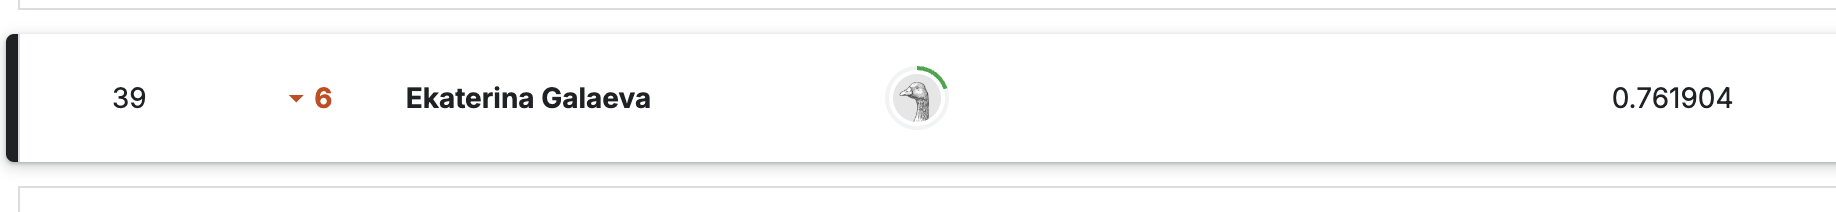
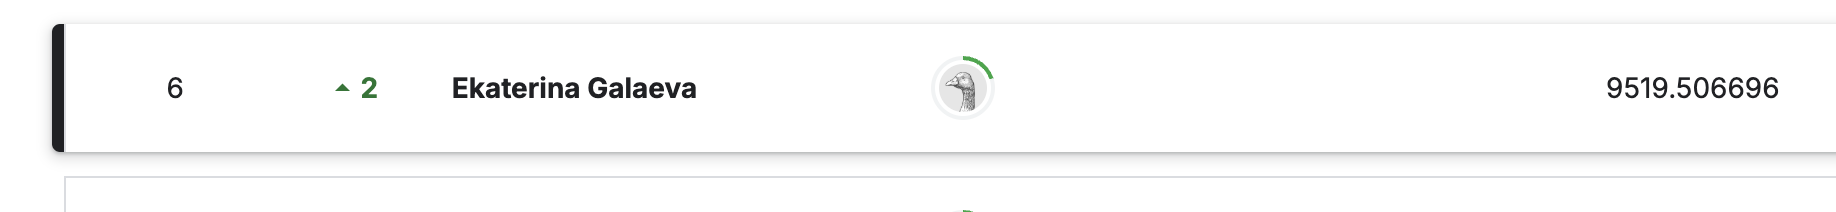

In [2]:
df_train = pd.read_csv('train.csv')

In [3]:
df_train['target'].value_counts()

target
0    781927
1      4504
Name: count, dtype: int64

In [4]:
df_test = pd.read_csv('test.csv')
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 262144 entries, 0 to 262143
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_time  262144 non-null  object 
 1   merch             262144 non-null  object 
 2   cat_id            262144 non-null  object 
 3   amount            262144 non-null  float64
 4   name_1            262144 non-null  object 
 5   name_2            262144 non-null  object 
 6   gender            262144 non-null  object 
 7   street            262144 non-null  object 
 8   one_city          262144 non-null  object 
 9   us_state          262144 non-null  object 
 10  post_code         262144 non-null  int64  
 11  lat               262144 non-null  float64
 12  lon               262144 non-null  float64
 13  population_city   262144 non-null  int64  
 14  jobs              262144 non-null  object 
 15  merchant_lat      262144 non-null  float64
 16  merchant_lon      26

In [5]:
df_train

,transaction_time,merch,cat_id,amount,name_1,name_2,gender,street,one_city,us_state,post_code,lat,lon,population_city,jobs,merchant_lat,merchant_lon,target
0,2019-12-27 15:21,fraud_Cormier LLC,health_fitness,148.04,Daniel,Martinez,M,8510 Acevedo Burgs,Kent,OR,97033,45.0838,-120.6649,60,Museum education officer,45.042827,-120.709327,0
1,2019-04-17 23:09,"fraud_Brown, Homenick and Lesch",health_fitness,39.40,Grace,Williams,F,28812 Charles Mill Apt. 628,Plantersville,AL,36758,32.6176,-86.9475,1412,Drilling engineer,31.872266,-87.828247,0
2,2019-09-23 15:02,fraud_Ruecker-Mayert,kids_pets,52.96,Kyle,Park,M,7507 Larry Passage Suite 859,Mount Perry,OH,43760,39.8788,-82.1880,1831,Barrister's clerk,40.010874,-81.841249,0
3,2019-05-13 16:00,"fraud_Mante, Luettgen and Hackett",health_fitness,7.66,Monique,Martin,F,68276 Matthew Springs,Ratcliff,TX,75858,31.3833,-95.0619,43,"Engineer, production",30.888406,-95.141609,0
4,2019-08-18 07:27,fraud_Luettgen PLC,gas_transport,51.59,Christine,Johnson,F,8011 Chapman Tunnel Apt. 568,Blairsden-Graeagle,CA,96103,39.8127,-120.6405,1725,Chartered legal executive (England and Wales),39.376017,-121.311691,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
786426,2019-04-10 12:35,"fraud_O'Connell, Botsford and Hand",home,76.56,Ryan,Foster,M,03921 Cole Mission Suite 882,Hampton,FL,32044,29.8575,-82.1483,2060,Oncologist,29.235257,-82.407844,0
786427,2019-12-15 09:34,"fraud_Adams, Kovacek and Kuhlman",grocery_net,68.58,Jim,Johnson,M,868 Brady Mill Apt. 837,Gretna,LA,70056,29.8872,-90.0331,55581,Biomedical scientist,29.015274,-90.564712,0
786428,2019-10-12 10:22,"fraud_Lind, Huel and McClure",gas_transport,66.66,Christopher,Horn,M,956 Sanchez Highway,Mallie,KY,41836,37.2692,-82.9161,798,Facilities manager,37.515508,-82.443788,0
786429,2019-10-18 09:01,fraud_Rempel PLC,grocery_net,38.06,Samuel,Sandoval,M,0005 Morrison Land,Mounds,OK,74047,35.8896,-96.0887,7163,Fitness centre manager,35.203864,-96.999902,0


In [6]:
df_train.describe()

,amount,post_code,lat,lon,population_city,merchant_lat,merchant_lon,target
count,786431.000000,786431.000000,786431.000000,786431.000000,7.864310e+05,786431.000000,786431.000000,786431.000000
mean,70.241296,48802.521336,38.527972,-90.224069,8.928853e+04,38.527301,-90.224508,0.005727
std,161.091489,26896.564152,5.078756,13.754760,3.028600e+05,5.113222,13.766977,0.075461
min,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,19.027804,-166.670132,0.000000
25%,9.650000,26237.000000,34.620500,-96.798000,7.430000e+02,34.727480,-96.901593,0.000000
50%,47.410000,48174.000000,39.346500,-87.476900,2.456000e+03,39.357665,-87.436919,0.000000
75%,83.000000,72042.000000,41.894800,-80.158000,2.047800e+04,41.950609,-80.233429,0.000000
max,27390.120000,99783.000000,66.693300,-67.950300,2.906700e+06,67.441518,-66.955996,1.000000


In [7]:
df_train['transaction_time'] = pd.to_datetime(df_train['transaction_time'])

df_train['year'] = df_train['transaction_time'].dt.year
df_train['month'] = df_train['transaction_time'].dt.month
df_train['day'] = df_train['transaction_time'].dt.day
df_train['hour'] = df_train['transaction_time'].dt.hour
df_train['minute'] = df_train['transaction_time'].dt.minute
df_train['day_of_week'] = df_train['transaction_time'].dt.dayofweek

In [8]:
df_test['transaction_time'] = pd.to_datetime(df_test['transaction_time'])

df_test['year'] = df_test['transaction_time'].dt.year
df_test['month'] = df_test['transaction_time'].dt.month
df_test['day'] = df_test['transaction_time'].dt.day
df_test['hour'] = df_test['transaction_time'].dt.hour
df_test['minute'] = df_test['transaction_time'].dt.minute
df_test['day_of_week'] = df_test['transaction_time'].dt.dayofweek

In [9]:
numeric_features = [
    'amount', 'ts_transaction_time', 'lat', 'lon', 'population_city', 'merchant_lat', 'merchant_lon'
]

cat_columns = [
    'merch', 'cat_id', 'name_1', 'name_2', 'gender', 'street', 'one_city', 'us_state', 'jobs', 'year',	'month',	'day',	'hour',	'minute'	,'day_of_week'
]

In [10]:
import numpy as np
from math import atan2, cos, radians, sin, sqrt


def haversine_distance(lat1: float, lon1: float, lat2: float, lon2: float, n_digits: int = 0) -> float:
    """
        Функция для расчёта расстояния от точки А до Б по прямой

        :param lat1: Широта точки А
        :param lon1: Долгота точки А
        :param lat2: Широта точки Б
        :param lon2: Долгота точки Б
        :param n_digits: Округляем полученный ответ до n знака после запятой
        :return: Дистанция по прямой с точностью до n_digits
    """

    lat1, lon1, lat2, lon2 = round(lat1, 6), round(lon1, 6), round(lat2, 6), round(lon2, 6)
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)

    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2) ** 2

    return round(2 * 6372800 * np.arctan2(np.sqrt(a), np.sqrt(1 - a)), n_digits)  # метры.сантиметры


def bearing_degree(lat1: float, lon1: float, lat2: float, lon2: float, n_digits: int = 0) -> float:
    """
        Функция для расчёта угла между прямой [((lat1, lon1), (lat2, lon2)), (нулевой мередиан)]

        :param lat1: Широта точки А
        :param lon1: Долгота точки А
        :param lat2: Широта точки Б
        :param lon2: Долгота точки Б
        :param n_digits: Округляем полученный ответ до n знака после запятой
        :return: Значение угла с точностью до n_digits
    """

    lat1, lon1 = np.radians(round(lat1, 6)), np.radians(round(lon1, 6))
    lat2, lon2 = np.radians(round(lat2, 6)), np.radians(round(lon2, 6))

    dlon = (lon2 - lon1)
    numerator = np.sin(dlon) * np.cos(lat2)
    denominator = np.cos(lat1) * np.sin(lat2) - (np.sin(lat1) * np.cos(lat2) * np.cos(dlon))

    theta = np.arctan2(numerator, denominator)
    theta_deg = (np.degrees(theta) + 360) % 360

    return round(theta_deg, n_digits)

In [11]:
df_train['bearing_degree_1'] = bearing_degree(df_train['lat'], df_train['lon'], df_train['merchant_lat'], df_train['merchant_lon'], ).values
df_test['bearing_degree_1'] = bearing_degree(df_test['lat'], df_test['lon'], df_test['merchant_lat'], df_test['merchant_lon'], ).values

In [12]:
df_train['hav_dist_1'] = haversine_distance(df_train['lat'], df_train['lon'], df_train['merchant_lat'], df_train['merchant_lon'], ).values
df_test['hav_dist_1'] = haversine_distance(df_test['lat'], df_test['lon'], df_test['merchant_lat'], df_test['merchant_lon'], ).values

In [13]:
model_features = [
  'amount',
  'bearing_degree_1',
  #'bearing_degree_2',
  #'bearing_degree_3',
  'cat_id',
  'gender',
  'hav_dist_1',
  #'hav_dist_2',
  #'hav_dist_3',
  'jobs',
  'lat',
  'lon',
  'merch',
  #'merchant_lat',
  #'merchant_lon',
  'name_1',
  'name_2',
  'one_city',
  'population_city',
  #'post_code',
  'street',
  'us_state',
  'year',	
  'month',	
  'day',	
  'hour',	
  'minute',
  'day_of_week'
]

In [14]:
X = df_train.drop("target", axis=1) 
y = df_train["target"]

In [15]:
X.columns

Index(['transaction_time', 'merch', 'cat_id', 'amount', 'name_1', 'name_2',
       'gender', 'street', 'one_city', 'us_state', 'post_code', 'lat', 'lon',
       'population_city', 'jobs', 'merchant_lat', 'merchant_lon', 'year',
       'month', 'day', 'hour', 'minute', 'day_of_week', 'bearing_degree_1',
       'hav_dist_1'],
      dtype='object')

In [16]:
numeric_feat = ['amount','lat', 'lon', 'population_city', 'merchant_lat', 'merchant_lon', 'year',
       'month', 'day', 'hour', 'minute', 'day_of_week', 'bearing_degree_1',
       'hav_dist_1']

/var/folders/rm/c6dtgnt92mncnb60whf8_fqm0000gn/T/ipykernel_80350/1299369460.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  formatted_corr = corr_matrix.applymap(lambda x: "0.00" if abs(x) < 1e-1 else f"{x:.2f}")


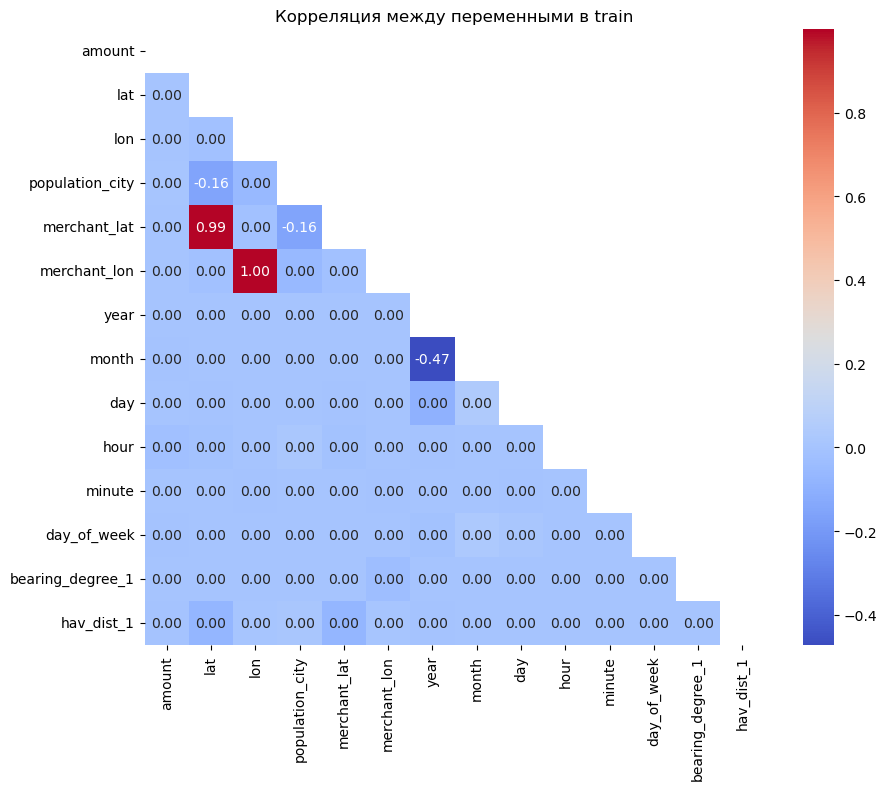

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = X[numeric_feat].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

formatted_corr = corr_matrix.applymap(lambda x: "0.00" if abs(x) < 1e-1 else f"{x:.2f}")

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, mask=mask, annot=formatted_corr, fmt="", cmap="coolwarm")
plt.title("Корреляция между переменными в train")
plt.show()


Фича merchant_lat сильно коррелирует с merchant_lon

In [18]:
X = df_train.drop("merchant_lat", axis=1) 

In [19]:
#cat_features_indices = [X.columns.get_loc(col) for col in cat_features if col in X.columns]
#cat_features_indices

Балансировка классов в выборке с помощью метода случайного увеличения (RandomOverSampler) из библиотеки imblearn. Это делается для устранения проблемы дисбаланса классов, когда один класс значительно преобладает над другим. В результате, после ресэмплинга, каждый класс представлен равномерно, что может улучшить качество обучения модели.

In [20]:
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X[model_features], y)
print("Распределение классов после RandomOverSampler:")
print(pd.Series(y_train_res).value_counts())

Распределение классов после RandomOverSampler:
target
0    781927
1    781927
Name: count, dtype: int64


Разделим выборку на траин, вал и тест

In [21]:

X_train, X_test, y_train, y_test = train_test_split(X_train_res, y_train_res, test_size=0.25, random_state=42)


In [22]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)


Сделаем подбор гиперпараметров с помощью GridSearch. С помощью него были найдены лучшие параметры: 

    - iterations=500,        
    - learning_rate=0.01,      
    - depth=3

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'iterations': [100, 200, 500],
    'learning_rate': [ 0.1, 0.03],
    'depth': [1, 2, 3, 5, 7]
}

clf = CatBoostClassifier(
    verbose=False,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=1 
)


best_model = grid_search.fit(X_train, y_train, eval_set=(X_val, y_val), cat_features=cat_columns, early_stopping_rounds=50)


print("Лучшие гиперпараметры:", grid_search.best_params_)
print("Лучший результат кросс-валидации:", grid_search.best_score_)


In [ ]:
test_score = best_model.score(X_test, y_test)
print("Результат на тестовой выборке:", test_score)

Результат на валидационной выборке: 0.999994884439488


In [ ]:
y_pred =best_model.predict(X_test)
test_score = best_model.score(y_pred, y_test)
print("Результат на тестовой выборке:", test_score)

In [24]:
from catboost import CatBoostClassifier

clf = CatBoostClassifier(
    iterations=500,        
    learning_rate=0.01,      
    depth=3,                
    random_state=42,
    verbose=False
)


clf.fit(X_train, y_train, eval_set=(X_val, y_val), cat_features=cat_columns, early_stopping_rounds=50)


val_score = clf.score(X_val, y_val)
print("Результат на валидационной выборке:", val_score)


Результат на валидационной выборке: 0.999952254768555


In [25]:

clf.save_model("catboost_model.cbm")

In [36]:
y_pred =clf.predict(X_test)
test_score = clf.score(y_pred, y_test)
print("Результат на тестовой выборке:", test_score)

Результат на тестовой выборке: 0.4989794456778629


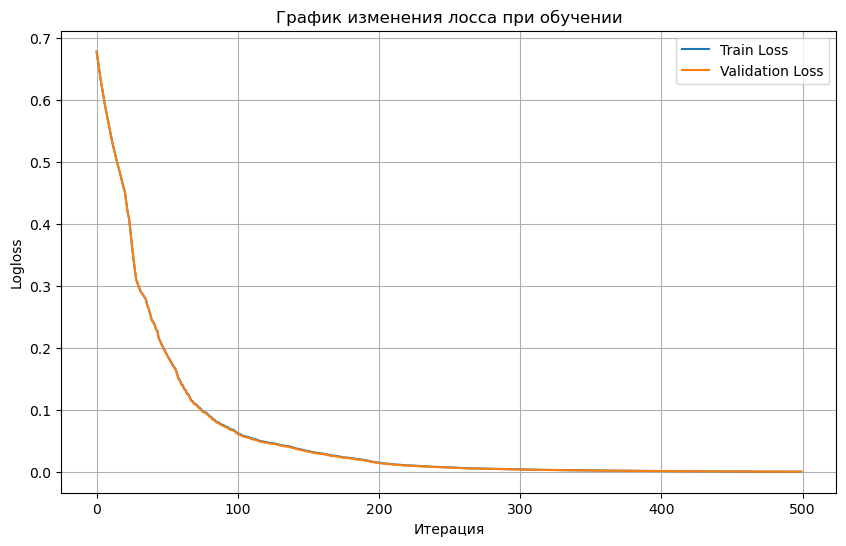

In [37]:
evals_result = clf.get_evals_result()

train_loss = evals_result['learn']['Logloss']
val_loss = evals_result['validation']['Logloss']

plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Итерация')
plt.ylabel('Logloss')
plt.title('График изменения лосса при обучении')
plt.legend()
plt.grid(True)
plt.show()


На графике изображены кривые изменения функции потерь на обучающей и валидационной выборках по итерациям обучения:

1. Оба лосса последовательно убывают с ростом числа итераций, что говорит о том, что модель учится и становится точнее.  
2. Кривые постепенно выходят на плато, что говорит о близости к оптимальному уровню качества.  
3. Отсутствует значительный разрыв, указывающий на сильное переобучение; значит, модель сохраняет способность к обобщению.  


In [38]:
df_test=df_test[model_features]

In [39]:
y_pred = clf.predict(df_test)

In [40]:
submission = pd.DataFrame({'prediction': y_pred})

submission = submission.reset_index()

submission.rename(columns={'index': 'index', 'prediction': 'prediction'}, inplace=True)

submission.to_csv("submission.csv", index=False)

In [41]:
submission['prediction'].value_counts()

prediction
0    261168
1       976
Name: count, dtype: int64


### Outro 

1. **Расширение набора признаков**  
   - Добавление новых признаков, основанных на более глубоком анализе временных и пространственных данных, может выявить скрытые зависимости и повысить качество модели.  
  
     -      Рассчитать дополнительные временные признаки (например, сезонность, разница между временными отрезками) и пространственные метрики (например, кластеризацию географических точек).  
     -      Провести эксперименты с новым набором признаков и оценить их влияние на итоговую метрику.

2. **Использование более сложных методов оптимизации гиперпараметров**  
   - Тщательный подбор гиперпараметров может значительно повысить производительность модели.  
   
   
     -      Определить более широкий диапазон значений для гиперпараметров и провести серию итеративных экспериментов для выявления оптимальных настроек.  

3. **Построение ансамблевой модели**  
   - Ансамблирование моделей позволяет объединить сильные стороны нескольких алгоритмов, что часто приводит к более стабильным и точным предсказаниям.  

     -      Попробовать комбинировать CatBoost с другими алгоритмами, такими как LightGBM или XGBoost, используя методы стекинга или блендинга.  
     -      Провести кросс-валидацию для оценки вклада каждой модели в общий ансамбль.  
     -      Настроить веса для каждого базового классификатора.
